In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 필요 라이브러리 설치
!pip install statsmodels

# 코랩에서 한글 폰트 사용을 위한 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 런타임 다시 시작 안내
# 위 코드 실행 후 상단 메뉴에서 [런타임] > [런타임 다시 시작]을 눌러주세요.
# 런타임을 다시 시작해야 한글 폰트가 적용됩니다.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (11.6 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and direct

In [ ]:
# 런타임 다시 시작 후, 이 셀을 실행하여 라이브러리와 폰트를 로드합니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 한글 폰트 설정
plt.rc('font', family='NanumGothic')
# plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# Medical Cost Analysis

- **데이터 분석자 : C4조** <br>
- **조원 : 윤준성, 김수경, 박의진**<br>

## **프로젝트 개요**
본 프로젝트는 개인 특성(나이, 성별, BMI, 자녀 수, 흡연 여부, 거주 지역)에 따라 의료비(charges)가
어떻게 달라지는지를 데이터 기반으로 분석하는 것을 목표로 함.

주어진 데이터를 탐색하여 가설을 세우고(EDA),
통계적 방법으로 이를 검증하며(Hypothesis Testing),
더 나아가 변수 간의 관계를 수치로 예측(Regression)해보는 실습 프로젝트임

---
##**1. 데이터 로드 및 구조 확인**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/insurance.csv')

In [ ]:
# 1.1 데이터셋 로드
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
#1.2 데이터 구조 및 통계량 확인
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


###1.1 데이터 구조 확인 결과

	•	관측치 : 1338명
    •   변수: 7개
	•	결측치: 없음
	•	타입 분류:
	- 수치형: age, bmi, children, charges
	- 범주형: sex, smoker, region
###1.2 (의료비) 데이터 통계 확인 결과

	•	평균: 13,270
	•	중앙값: 9,382
	•	최대값: 63,770
	•	표준편차: 12,110
    
    : 표준편차 크고 중앙값보다 평균이 크고 최대값이 상당이 크다 - 오른쪽으로 치우친 비대칭 분포 예상:
    -> 정규성 가정이 의심됨. 분포 왜도 줄이고 극단값 영향을 완화하기 위한 로그변환, 비모수 검정 고려.

---
## **2. 데이터 품질 점검**

In [ ]:
##2.1 데이터 점검 (결측치)  - 없음 확인 : 중복 제거 과정 없이 분석 진행함.
df.isnull().sum()


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
##2.2 데이터 점검 (중복)  - 1개 확인
df.duplicated().sum()

np.int64(1)

In [ ]:
## 중복 행 확인 후 제거
df[df.duplicated(keep=False)].index
df = df.drop_duplicates().reset_index(drop=True)
df.duplicated().sum()

np.int64(0)

###2. 데이터 품질 점검 결과
 -> 결측은 없고 중복행 1개 관찰되어 제거함.

---
##**3.EDA 진행 및 문제 정의**
###3.1 **종속변수 의료비** 분포 확인

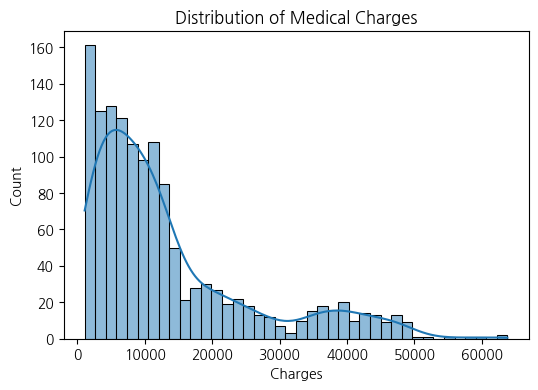

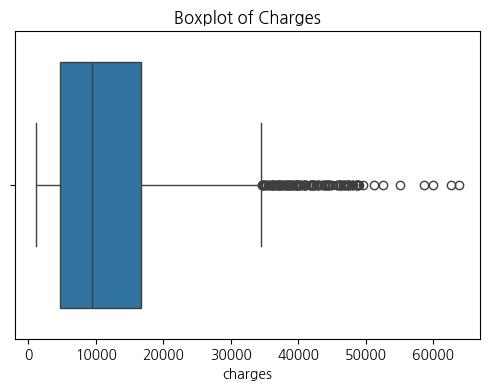

In [ ]:
#3.1 의료비(charges) 분포 확인
# 히스토그램으로 보기
plt.figure(figsize=(6,4))
sns.histplot(df['charges'], bins=40, kde=True)
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Count')
plt.show()

#박스플롯으로 보기
plt.figure(figsize=(6,4))
sns.boxplot(x=df['charges'])
plt.title('Boxplot of Charges')
plt.xlabel('charges')
plt.show()

###3.1 **의료비 분포** 확인 결과


*   히스토그램상으로 대부분 관측치가 낮은쪽에 집중되어있고, 일부 고액 의료비로 길게 오른쪽 꼬리를 가진 비대칭 분포(right-skewed) 확인함.
* 박스플롯 확인 결과에서도 중앙값이 박스 안에서 낮은값쪽에 위치, 고액쪽 아웃라이어 상당히 많음.
--> 의료비는 오른쪽 롱테일 구조를 갖는 비대칭 분포이며, 고액 의료비 이상치 사례가 전체 분포에 영향을 많이 미치고 있음.



###**[Pairplot으로 전체 한번에 시각화]**

pairplot으로 수치형 변수들 간의 관계를 전반적으로 탐색(각 변수 조합을 자동으로 x축과 y축에 배치)

* 의료비(charges)와 다른 변수 간의 전반적인 패턴을 확인한 후,
보다 명확한 관계가 관찰된 후보 변수를 골라 문제 정의를 하려고 함.

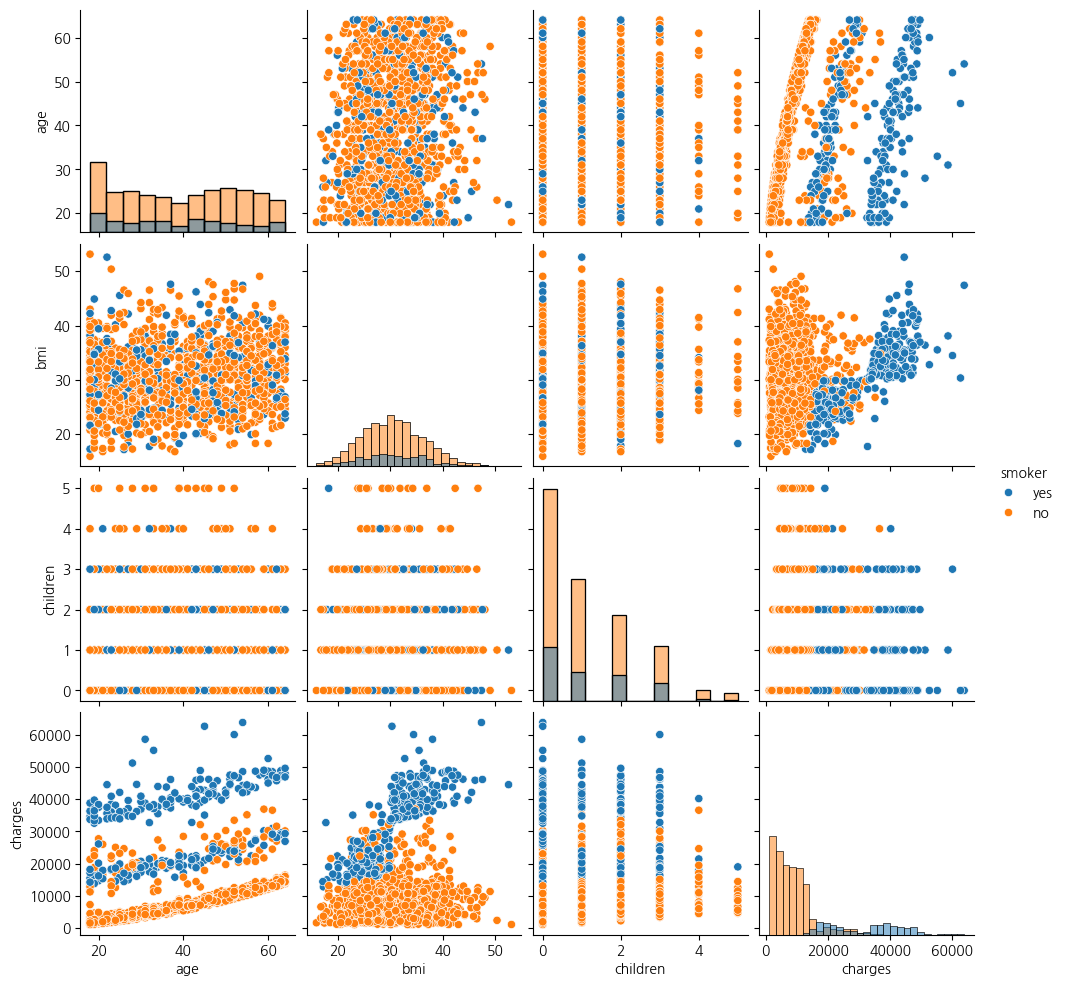

In [ ]:
# pairplot으로 전체 흐름 찾기
# vars : 수치형 변수만 해석 가능, charges 포함 -> 목표변수 고정, hue ='smoker' 흡연 효과 한눈에 보이게
sns.pairplot(
    df,
    vars=['age', 'bmi', 'children', 'charges'],
    hue='smoker',
    diag_kind='hist'
)
plt.show()

### 전반적으로 각 변수들과의 상관성을 본 결과

*   흡연유무에 따라 bmi와 의료비 간의 관계 양상이 달라지는 경향이 관찰됨.
*   흡연유무에 따라 의료비 높고 낮음이 확실이 분리되는 것이 보임. -> 흡연 여부가 의료비 분석에 중요한 변수로 작용할 가능성 시사

---
###3.2 **범주형 변수에서 영향력 높아보이는 후보 변수와 의료비 검토**
###**-> 질문 후보 만들기 1**
###**3.2 흡연 여부에 따른 의료비 비교 분석**


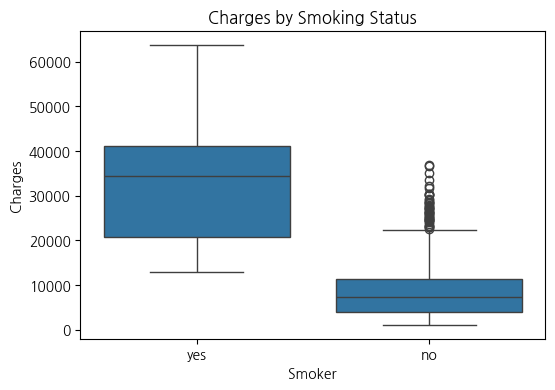

In [ ]:
#흡연 여부에 따른 의료비 박스 플롯
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

###3.2 **흡연 여부에 따른 의료비 비교 결과**
흡연자와 비흡연자간에 의료비 차이가 있어 보임.

*   흡연자 의료비가 비흡연자보다 중앙값과 분포가 높음
*   박스(IQR) 자체가 겹치는 범위가 아닌 것으로 보여서 해당 차이가 의료비에 중요 영향을 미칠 변수일 가능성 있음. -> 통계적으로 유의미한지 확인 필요






---
###3.3.**연속형 변수에서 영향력 높아보이는 후보변수과 의료비 검토**
### **-> 질문 후보 만들기 2**
### 3.3 **BMI와 의료비 관계 분석**



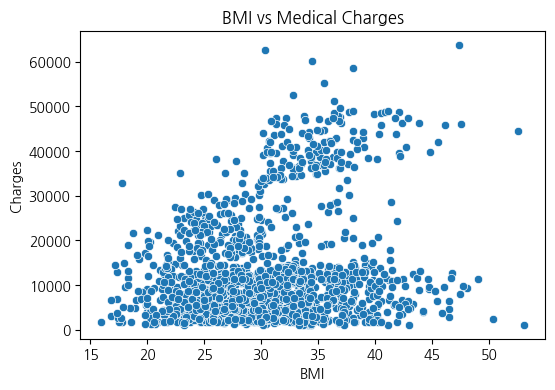

In [ ]:
#BMI와 의료비 산점도 그래프 그려보기
# BMI와 의료비 산점도
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('BMI vs Medical Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

### 3.3 BMI와 의료비 간 관계를 산점도로 확인한 결과


*   BMI가 커지면 높은 의료비들이 상대적으로 많이 존재하는 경향 확인
*   하지만 동일 BMI 구간에서의 의료비 변동폭이 크게 나타나 단일 변수만으로 의료비 설명하는데에는 한계가 있을것으로 예상 -> 보조변수를 이용해 추가 분석이 필요해보이는데 실습 시간 고려해서 진행 여부 판단



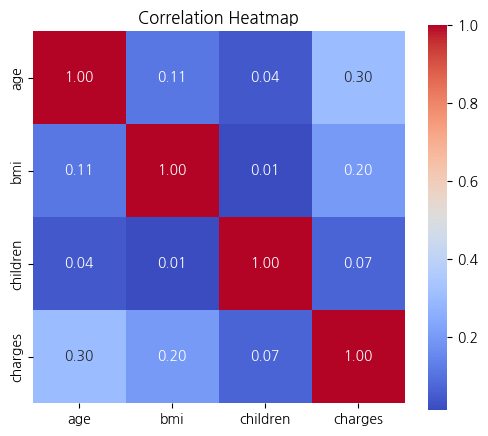

In [ ]:
#수치형 변수간의 상관계수 시각화

import seaborn as sns
import matplotlib.pyplot as plt

# 상관계수 히트맵 확인
corr = df[['age', 'bmi', 'children', 'charges']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

##**4. 탐색한 문제에 따른 두 가지 가설 설정**
###**(가설 1) 서로 독립적인 두 집단 (흡연자 vs. 비흡연자) 평규 의료비가 다른가?**

*   비교대상 : 흡연자, 비흡연자
*   관심값 : 평균
*   종속변수 : 의료비
*   검정법 : 두 독립변수 간 평균 차이 분석이라 t-test 고려할 수 있으나 EDA에서 의료비 분포가 비대칭적이며 이상치가 다수 관찰되었고, 흡연 여부에 따라 분산이 다를 가능성이 있어 등분산을 가정하지 않는 **Welch t-test**를 사용.
또한 정규성 가정이 약할 가능성을 고려해 **Mann–Whitney U test**(비모수 검정)도 함께 고려.

- 귀무가설 : 두 집단의 평균 의료비가 같다.
- 대립가설 : 두 집단의 평균 의료비가 다르다.

###**(가설 2) BMI는 의료비(Charges)와 통계적으로 유의미한 관계를 가지는가?**
단, EDA에서 BMI와 의료비 간의 상관관계는 많이 높아보이진 않고, 흡연 여부에 따라 달라질 가능성이 관찰되어, 이후 추가설명 변수로 흡연유무를 고려하기로 함.
*   설명 변수(X) : BMI  (필요 시 추가 설명변수로 흡연 컬럼 고려)
*   종속 변수(Y) : 상관계수
*   관심값 : 회귀계수(기울기) 및 유의확률(p-value)
*   검정/모형 선택 근거 : BMI와 의료비 관계는 선형회귀 사용, EDA에서 BMI-의료비 관계 양상이 흡연 여부로 갈리는 경향이 관찰되어, smoker를 추가 설명 변수로 포함하는 다중회귀를 확장 분석으로 고려

- 귀무가설 : BMI와 의료비(charges) 간에는 통계적으로 유의미한 관계가 없다.  
- 대립가설 : BMI와 의료비(charges) 간에는 통계적으로 유의미한 관계가 있다.

---
##**5.가설1 분석 (담당자: 김수경 그루)**

###**(가설 1) 서로 독립적인 두 집단 (흡연자 vs. 비흡연자) 평규 의료비가 다른가?**

*   비교대상 : 흡연자, 비흡연자
*   관심값 : 평균
*   종속변수 : 의료비
*   검정법 : 두 독립변수 간 평균 차이 분석이라 t-test 고려할 수 있으나 EDA에서 의료비 분포가 비대칭적이며 이상치가 다수 관찰되었고, 흡연 여부에 따라 분산이 다를 가능성이 있어 등분산을 가정하지 않는 **Welch t-test**를 사용.
또한 정규성 가정이 약할 가능성을 고려해 **Mann–Whitney U test**(비모수 검정)도 함께 고려.

- 귀무가설 : 두 집단의 평균 의료비가 같다.
- 대립가설 : 두 집단의 평균 의료비가 다르다.

### **분석 방법 선택 및 정당화**

먼저 흡연 여부와 의료비를 독립 및 종속 변수로 지정했습니다.

독립변수 : 흡연자 / 비흡연자 2개 집단 (범주형)
종속변수 : 의료비 (연속형)

두 독립 집단의 평균 차이를 검정하는 대표적인 방법은 독립표본 t-test로 이 데이터들 간에 정규성이 있는지 등분산성이 있는지를 확인해보았습니다.

<Axes: xlabel='charges', ylabel='Count'>

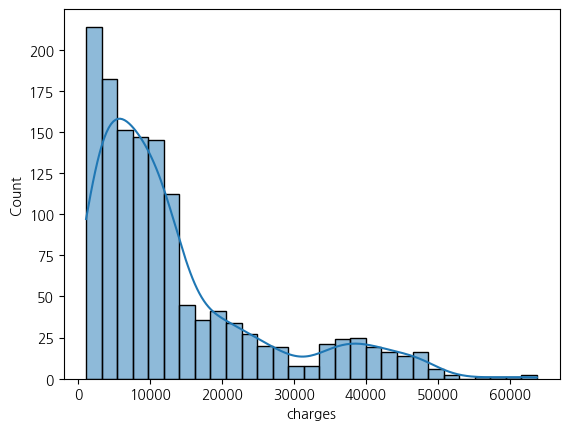

In [ ]:
# 의료비 정규성 확인
sns.histplot(df['charges'], kde=True)

<Axes: xlabel='smoker', ylabel='charges'>

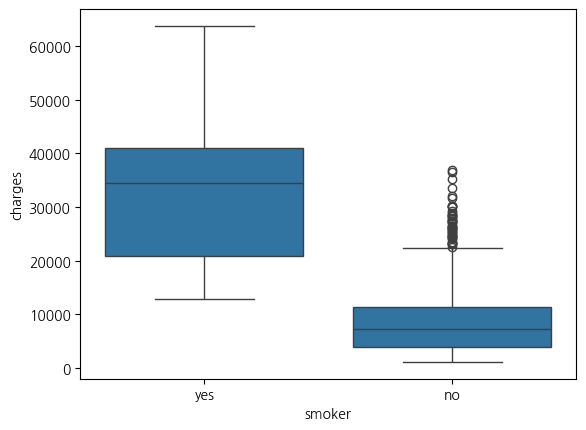

In [ ]:
# 흡연 여부 등분산성 확인
sns.boxplot(x='smoker', y='charges', data=df)

**1. 의료비 정규성 확인**
- 히스토그램을 통해 의료비 분포를 확인한 결과, 의료비는 낮은 값에 집중되어있고 일부 고액 의료비가 길게 분포하는 형태를 보였습니다.
- 특히 상위 구간으로 갈수록 소수의 매우 큰 값들이 존재해 분포가 오른쪽으로 치우친 우측 비대칭 형태임을 알 수 있었습니다.

**2. 흡연 여부 등분산성 확인**
- boxplot을 통해 흡연 여부 분포를 확인한 결과, 흡연자의 중앙값이 비흡연자보다 매우 높은 것으로 확인되었습니다.
- 흡연자는 IQR 자체가 비흡연자 전체 분포보다 위쪽에 있어 전반적으로 고액 의료비 구간에 위치해있고, 비흡연자는 낮은 의료비 구간에 밀집되어있지만 일부 이상치가 고액 구간에 존재하는 것으로 보입니다.
- 비흡연자도 고액 의료비가 있지만 흡연자 분포의 중앙 영역보다도 낮은 수준으로 일부 예외가 있어도 전체 경향은 변하지 않은 것으로 보입니다.

이와 같이 의료비는 비정규성, 흡연/비흡연 집단의 분산도 서로 다르게 나타나 등분산 가정을 만족하기 어렵다고 판단했습니다.

이때 **분산이 일치하지 않는 t검정은 웰치의 t검정을 이용**하기 때문에 해당 통계 기법으로 진행해보았습니다.

In [ ]:
import numpy as np
from scipy import stats

# 그룹 나누기
smoker_yes = df[df['smoker'] == 'yes']['charges']
smoker_no  = df[df['smoker'] == 'no']['charges']

# ================================
# 1. 정규성 검정 (Shapiro-Wilk test)
# H₀: 데이터는 정규분포를 따른다.
# ================================
shapiro_yes_pvalue = stats.shapiro(smoker_yes).pvalue
shapiro_no_pvalue  = stats.shapiro(smoker_no).pvalue

print(f"흡연자 그룹 정규성 검정 p-value: {shapiro_yes_pvalue:.4e}")
print(f"비흡연자 그룹 정규성 검정 p-value: {shapiro_no_pvalue:.4e}")

# ================================
# 2. 등분산성 검정 (Levene's test)
# H₀: 두 그룹의 분산은 같다.
# ================================
levene_pvalue = stats.levene(smoker_yes, smoker_no).pvalue
print(f"\n등분산성 검정 p-value: {levene_pvalue:.4e}")

# ================================
# 3. 독립표본 t-test
# H₀: 두 그룹의 평균은 같다.
# ================================
equal_var = levene_pvalue >= 0.05

t_statistic, p_value = stats.ttest_ind(smoker_yes,
                                       smoker_no,
                                       equal_var=equal_var)

print("\n독립표본 t-test 결과")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.4e}")

흡연자 그룹 정규성 검정 p-value: 3.6250e-09
비흡연자 그룹 정규성 검정 p-value: 1.5035e-28

등분산성 검정 p-value: 1.6701e-66

독립표본 t-test 결과
t-statistic: 32.7423
p-value: 6.2617e-103


분석을 통해 t-test p-value를 확인한 결과, 6.2617의 10의 마이너스 103승으로 **사실상 0에 가까운 값**임을 확인할 수 있었습니다.

유의 수준 0.05보다 훨씬 작은 값이므로 귀무가설을 기각할 충분한 근거가 있다고 볼 수 있었습니다.


## **결론**

**대립가설**인 '흡연자와 비흡연자 간 평균 의료비(charges)에 유의미한 차이가 있다.'를 지지할 근거가 충분하다.



---


그러나 의료비는 흡연 여부 외에도 연령과 같은 개인 특성의 영향을 받을 수 있으므로, 관찰된 차이가 연령 분포 차이에 의해 설명되는 것은 아닌지 추가적으로 확인해봤습니다.

그중 ‘나이’를 선택한 이유는 연령이 증가할수록 질병 발생 가능성이 높아지고 이에 따라 의료비가 증가할 수 있기 때문입니다.

이에 따라 **나이와 의료비 간의 관계를 흡연 여부에 따라 시각화**하여 살펴보고, 동일한 연령대에서도 흡연자와 비흡연자 간 의료비 수준에 차이가 존재하는지 확인하였습니다.

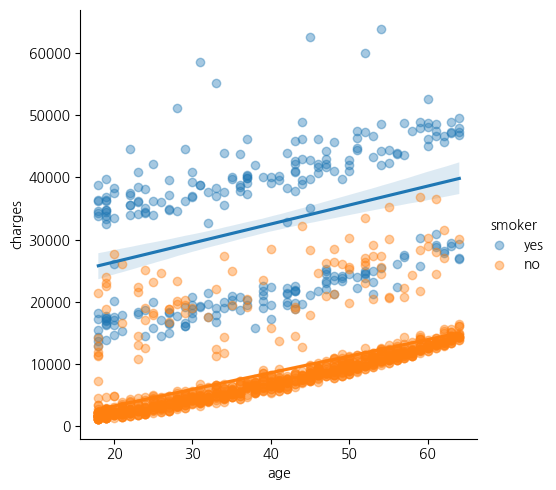

In [ ]:
sns.lmplot(
    x='age',
    y='charges',
    hue='smoker',
    data=df,
    scatter_kws={'alpha':0.4}
)
plt.show()

파란 선은 흡연자만을 대상으로 계산한 회귀선이며, 주황 선은 비흡연자만을 대상으로 계산한 회귀선입니다.

흡연자 회귀선이 전체적으로 위에 위치해 동일한 연령에서도 흡연자의 의료비가 더 높은 수준임을 확인할 수 있었고, 또한 나이가 증가할수록 의료비가 증가하는 경향은 두 집단 모두에서 관찰되었으며, 흡연자에서 증가 폭이 더 커 보이는 시각적 차이가 존재했습니다.

###  **가설 1 검정에 따른 결론**

흡연자와 비흡연자 간 평균 의료비 차이는 단순 평균 비교뿐 아니라 분포 전반에서 뚜렷하게 나타났으며, 이는 흡연 여부가 의료비 수준을 구조적으로 구분하는 핵심 요인으로 볼 수 있었습니다. 특히 동일한 연령대에서도 흡연자의 의료비가 전반적으로 더 높은 수준에 분포하는 점을 통해 관찰된 의료비 차이가 단순히 연령 분포 차이에 발생한 결과가 아님을 확인할 수 있었습니다.

---
##6.**가설2 분석 (담당자: 박의진 그루)**

###**(가설 2) BMI는 의료비(Charges)와 통계적으로 유의미한 관계를 가지는가?**
단, EDA에서 BMI와 의료비 간의 상관관계는 많이 높아보이진 않고, 흡연 여부로 구분되는 패턴이 관찰되어, 이후 추가설명 변수로 흡연유무를 고려하기로 함.
*   설명 변수(X) : BMI  (필요 시 추가 설명변수로 흡연 컬럼 고려)
*   종속 변수(Y) : 의료비
*   관심값 : 회귀계수(기울기) 및 유의확률(p-value)
*   검정/모형 선택 근거 : BMI와 의료비 관계는 선형회귀 사용, EDA에서 BMI-의료비 관계 양상이 흡연 여부로 갈리는 경향이 관찰되어, smoker를 추가 설명 변수로 포함하는 다중회귀를 확장 분석으로 고려

- 귀무가설 : BMI와 의료비(charges) 간에는 통계적으로 유의미한 관계가 없다.  
- 대립가설 : BMI와 의료비(charges) 간에는 통계적으로 유의미한 관계가 있다.


### 6-1. **BMI와 의료비의 관계성 확인**


*   1단계 : 관계가 있긴 하냐?
*   2단계 : 있다면 얼마나 강하냐?
*   3단계 : 그 관계를 수식으로 표현할 수 있냐? -> 회귀



In [ ]:
from scipy.stats import pearsonr, spearmanr

#회귀분석에 앞서서 전반적인 두 변수간 관계 존재여부를 확인하기 위해 상관계수들 확인함.
# Pearson 상관계수 (선형 관계를 봄. 정규성 가정 -> "BMI가 커질수록 의료비가 직선으로 증가하냐?")
pearson_corr, pearson_p = pearsonr(df['bmi'], df['charges'])

# Spearman 상관계수 (순위 기반, 비정규에  -> "BMI가 커질수록 의료비가 전반적으로 커지는 경향이 있나?")
spearman_corr, spearman_p = spearmanr(df['bmi'], df['charges'])

pearson_corr, pearson_p, spearman_corr, spearman_p

(np.float64(0.19840083122624938),
 np.float64(2.4680404264513685e-13),
 np.float64(0.11958495819244366),
 np.float64(1.1637179203181515e-05))

### 상관계수 분석 결과 (-1~+1 범위의 상관계수로 절대값으로 강도 해석, 부호는 방향)
	•	Pearson r = 0.198, p-value ≈ 2.47e-13
	•	Spearman r = 0.119, p-value ≈ 1.16e-05
Pearson 및 Spearman 두 분석 결과 모두 BMI와 의료비 간에 약한 수준의 양의 상관관계가 있음을 보여준다. (통계적으로 유의미)
이는 산점도와 상관계수 히트맵에서 관찰된 바와 같이, BMI 단일 변수로는 의료비의 변동을 충분히 설명하기 어렵다는 점과 일치

###6.2 **BMI 단순 선형회귀모델** 적용해서 해당 관계를 수식으로 표현할 수 있는지 진행

In [ ]:
import statsmodels.api as sm

#데이터 분리
X = df['bmi']
y = df['charges']

X = sm.add_constant(X)  # 상수항 절편 추가
model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.70
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           2.47e-13
Time:                        04:45:42   Log-Likelihood:                -14440.
No. Observations:                1337   AIC:                         2.888e+04
Df Residuals:                    1335   BIC:                         2.889e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1202.1404   1664.857      0.722      0.470   -2063.880    4468.161
bmi          393.8559     53.252      7.396      0.000     289.390     498.322
==============================================================================
Omnibus:                      260.633   Durbin-Watson:                   1.985
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              430.246
Skew:                           1.296   Prob(JB):                     3.74e-94
Kurtosis:                       4.002   Cond. No.                         160.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 6.2 **단순 선형회귀모델링 결과해석 -> BMI와 의료비 관계를 선형회귀식으로 표현 가능 확인**


*  BMI의 회귀계수(기울기)는 약 393.86으로 나타났으므로,<br>
이는 BMI가 1 증가할 때 의료비가 평균적으로 약 394달러 증가함을 의미<br>
해당 계수의 p-value는 0.001보다 작은 값으로,<br>
**BMI와 의료비 간의 관계는 통계적으로 유의미한 것으로 판단**<br>

* 다만 **결정계수(R²)는 약 0.039**로 나타나,BMI 변수는 의료비 변동의 약 3.9%만을 설명할 수 있음<br>
**BMI 단일 변수만으로 의료비 변동을 충분히 설명하기에는 한계가 있음을 확인**<br>
(-> 상관분석 및 산점도에서 관찰된 결과와 일치)
* **따라서 EDA에서 강한 영향 변수로 관찰된 흡연 여부를 추가 설명변수로 포함하는 <br>
다중 선형회귀분석을 진행하면 설명력이 개선되는지를 추가로 검토해보면 좋을 듯함.**






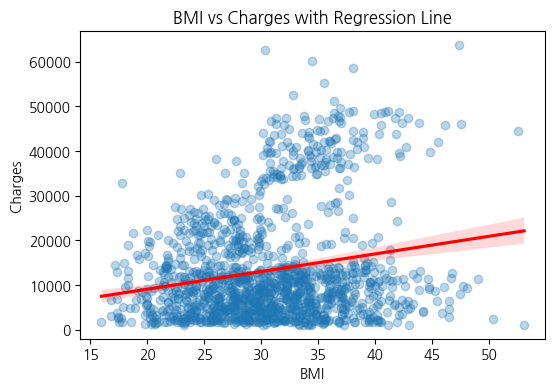

In [ ]:
#선형회귀 결과 시각화 : BMI 증가할수록 의료비 약하게 전반적으로 증가(하지만 점들이 회귀선 주변으로 넓게 퍼져 있음)
plt.figure(figsize=(6,4))
sns.regplot(x='bmi', y='charges', data=df,
            scatter_kws={'alpha':0.3},
            line_kws={'color':'red'})
plt.title('BMI vs Charges with Regression Line')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

---
###**6.3 (BMI-의료비) 선형회귀 타당성 점검을 위해 잔차(residual) plot 확인**
### 우리는 이 선형회귀 모델을 믿고 해석해도 될까?

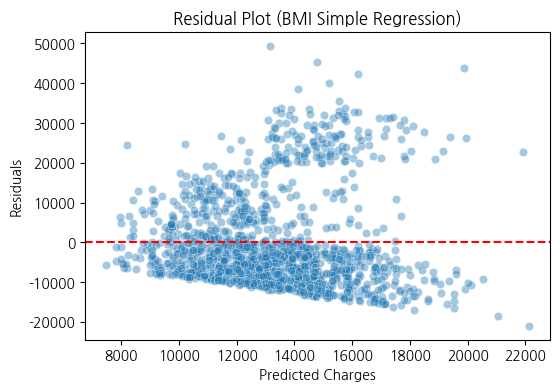

In [ ]:
df['pred'] = model_simple.predict(sm.add_constant(df['bmi']))
df['residual'] = df['charges'] - df['pred']

plt.figure(figsize=(6,4))
sns.scatterplot(x=df['pred'], y=df['residual'], alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.title('Residual Plot (BMI Simple Regression)')
plt.show()

###6.3 잔차 plot을 통한 오차 분산 분석 결과 <br>**: 이상적인 경우(회귀해석 신뢰가능) 잔차가 0 중심으로 무작위 흩어져있어야 함**

*   예측값이 커질수록 잔차 분산이 커지고 있음. -> 부채꼴 형태
*   잔차가 0 주변에 무작위로 퍼져있다기 보다는 음수 잔차가 모여있는 형태로 보임
*   **즉, 오차의 분산이 일정하지 않을 가능성 높음(등분산성 가정 위반)**
-> 해당 결과는 오차의 등분산성 가정이 완전히 만족되지 않을 가능성으로 인해 BMI 단일 변수만으로는 의료비 변동을 충분히 설명하기 역부족임을 시사함.




---
### 6.4 (추가 질문) **BMI 단일 변수 모델에 흡연 여부를 추가했을 때,의료비에 대한 설명력은 얼마나 개선되는가?**

In [ ]:
# 다순회귀모델과 다중회귀모델의 비교로 설명력 개선 여부 확인

# 단순 회귀 모델
X_simple = sm.add_constant(df['bmi'])
model_simple = sm.OLS(df['charges'], X_simple).fit()


# 다중 회귀 모델 (BMI + smoker)
df['smoker_dummy'] = df['smoker'].map({'yes': 1, 'no': 0})
X_multi = sm.add_constant(df[['bmi', 'smoker_dummy']])
model_multi = sm.OLS(df['charges'], X_multi).fit()

# R^2 비교 출력
print("=== 모델 설명력 비교 ===")
print(f"단순 회귀 (BMI): R² = {model_simple.rsquared:.3f}")
print(f"다중 회귀 (BMI + smoker): R² = {model_multi.rsquared:.3f}")
print(f"R² 증가량: {model_multi.rsquared - model_simple.rsquared:.3f}")

=== 모델 설명력 비교 ===
단순 회귀 (BMI): R² = 0.039
다중 회귀 (BMI + smoker): R² = 0.658
R² 증가량: 0.619


###6.4 **단순 vs. 다중 선형회귀모델링 비교로 흡연여부 추가 시 설명력 개선여부 확인**


*  BMI 단일 변수 회귀모델의 결정계수(R²)는 약 0.039었지만<br>
흡연 여부를 추가 설명변수로 포함한 다중 선형회귀 분석을 수행한 결과,<br>
모델의 결정계수(R²)는 약 0.658로 크게 증가<br>
**-> 따라서 의료비는 BMI와 같은 신체적 요인뿐 아니라,<br>
흡연 여부와 같은 생활습관 요인을 함께 고려하면<br>
보다 효과적으로 설명될 수 있음을 확인함**

###**[아래 시각화 결과 추가]**

*   흡연 여부에 따라 BMI–의료비 관계를 시각화하면, 두 집단의 회귀선이 뚜렷하게 구분되는 패턴을 보임.
*   **흡연자에서 기울기가 확 증가함.-> 설명력의 증가**






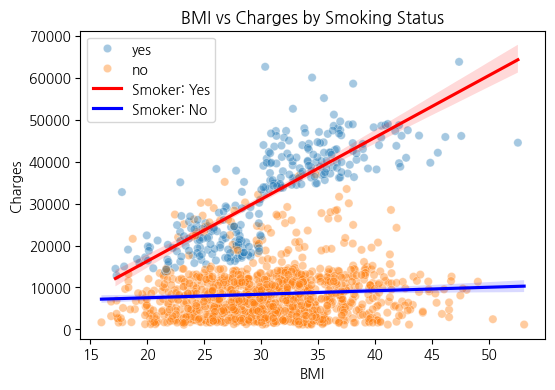

In [ ]:
## 단순 및 다중회귀 비교 결과 시각화
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.4)

sns.regplot(x='bmi', y='charges',
            data=df[df['smoker']=='yes'],
            scatter=False, label='Smoker: Yes', color='red')

sns.regplot(x='bmi', y='charges',
            data=df[df['smoker']=='no'],
            scatter=False, label='Smoker: No', color='blue')

plt.title('BMI vs Charges by Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.legend()
plt.show()

###6.5 **다중회귀에서의 다중공선성** 확인


In [ ]:
#다중회귀분석에서의 다중공선성 추가 확인
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

#설명변수 구성, 상수항 추가
X = df[['bmi', 'smoker_dummy']]
X = sm.add_constant(X)

# 다중공선성(VIF:Variance Inflation Factor) : 어떤 설명변수가 다른 설명변수들가 중복설명을 가지고 있는지 나타내는 지표로 분산팽창계수임
vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Variable,VIF
0,const,26.522694
1,bmi,1.000014
2,smoker_dummy,1.000014


### 6.5 **다중공선성(VIF) 결과 해석** (절편은 해석대상이 아니며 VIF값이 1(하한값)이면 거의 완전 독립, 1-5는 문제없음, 5-10 주의, 10 초과는 심각으로 일반적으로 해석함)

*   만약 BMI와 흡연이 서로 강하게 연결되어 있으면 각 변수의 순수한 효과를 분리하기 어려워 회귀계수 추정이 불안정해짐.
*   다중 선형회귀 모델에서 설명변수 간 다중공선성 여부를 확인하기 위해<br>
VIF(Variance Inflation Factor)를 산출함.<br>
분석 결과, BMI와 흡연 여부 변수의 VIF 값은 모두 1에 가까운 수준으로 나타나,<br>
설명변수 간 심각한 다중공선성 문제는 없는 것으로 판단<br>

**따라서 본 다중회귀 모델에서 추정된 회귀계수는 각 변수의 독립적인 효과를 안정적으로 반영한다고 볼 수 있다.**



###**6.6 가설 2 검정에 따른 결론**
BMI 단순 회귀모델의 결정계수(R²)는 약 0.039로 낮게 나타났으나,
흡연 여부를 추가한 다중 선형회귀 모델에서는 결정계수(R²)가 약 0.658로 크게 증가함.
이는 의료비가 단일 신체 지표보다는 흡연 여부와 같은 생활습관 요인을 함께 고려할 때
훨씬 효과적으로 설명될 수 있음을 의미한다고 볼 수 있음.

(-> 가설 1 역시 흡연이라는 생활습관이 얼마나 의료비 증가에 중요한 설명 변수인지를 확인할 수 있음. )

**종합적으로, 의료비는 BMI와 같은 신체적 요인뿐 아니라
흡연 여부와 같은 행동·생활습관 요인의 영향을 크게 받는 다요인적 변수이므로
보험료 책정 및 위험 관리 관점에서 개인의 신체적 요인과 생활관련 요인을 모두 고려한 종합적인 분석이 필요함을 시사함.**

###**[한계점 및 제언]**


1.   본 분석에서는 시간상 BMI와 흡연 여부를 중심으로 분석을 진행하였으나 연령(age), 자녀 수(children), 지역(region) 등 다른 변수들의 복합적인 영향은
충분히 고려하지 못함. 특히 변수 간 상호작용(interaction) 효과에 대한 분석은 포함되지 않음.
2.   데이터셋에 실제 의료비에 영향을 강하게 미칠 수 있는 개인의 의료 이용 행태, 질병 이력, 소득 수준, 흡연 강도 및 기간 정도 등 핵심 정보들이 없어서 비즈니스적으로 보험상품 설계를 위한 의료비 발생의 근본적 요인 찾기에는 한계가 있음.
3. 추가적으로 비선형적 접근 (로그 변환)등으로 분포 왜곡 문제를 완화하거나 상호작용 효과(효과가 상황에 따라 달라지는지) 분석을 수행한다면 의료비 구조에 대한 정교한 이해가 가능할 것임.
4. **참고로 오늘 알게된 점 :**  다중회귀는 변수의 독립적인 평균 효과를 보는 것이고, 상호작용 모형은 한 변수의 효과가 다른 변수에 따라 달라지는지를 보는 것임. 따라서 설명력을 높이기 위한 추가 변수를 보는 것은 지금처럼 다중회귀를 사용하면 되지만, 흡연유무에 따라서 BMI와 의료비와의 관계성이 어떻게 달라지는지 (예. 흡연하면 BMI 의 의료비 영향이 더 커지거나 작아지냐?-> 조건에 따라 효과가 달라지는지를 볼때) 상호작용 모형을 분석해야 한다.

